# 07 因子有效性检验：IC 与分层

## 7.1 本章要解决什么问题

第 06 章已经把 ETF 行情转成了 `date, code, factor...` 形式的因子面板。因子面板还不能直接进入回测：先要检查“今天的因子排序”和“未来一段收益”之间有没有稳定关系。

本章做三件事：

1. 把因子日 `t` 和未来 `t -> t+5` 的收益对齐。
2. 逐日计算 IC，分别理解 Spearman 排名相关和 Pearson 线性相关。
3. 做简单分层收益检查，观察高分组和低分组的未来收益是否有方向差异。

## 7.2 输入与输出

- 输入一：`data/sample/prices.parquet`，第 04 章缓存的真实 ETF 日线数据。
- 输入二：`outputs/results/chapter06_factor_panel.csv`，第 06 章产出的因子面板；如果这个文件不存在，本章会用本地缓存价格重建一份，便于单独运行。
- 输出：`outputs/results/factor_ic_summary.csv`。

## 7.3 重要限制

当前样例池只有 4 只 ETF。它足够用来学习对齐、IC 和分层的做法，但样本横截面很小，不能据此声称存在可交易 alpha。这里的结果只作为进入回测前的“体检表”，不是策略收益承诺。


In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "lib").exists() and (candidate / "data").exists():
            return candidate
        nested = candidate / "pyquant-roadmap"
        if (nested / "lib").exists() and (nested / "data").exists():
            return nested
    raise RuntimeError("Cannot find pyquant-roadmap project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

from lib.data import load_sample_prices
from lib.factors import build_technical_factor_panel, combine_score, zscore_by_date
from lib.factors.research import (
    add_forward_returns as add_forward_returns_lib,
    ic_by_date as ic_by_date_lib,
    layer_forward_returns as layer_forward_returns_lib,
    summarize_ic,
    summarize_layer_returns,
)
from lib.paths import RESULTS_DIR

FACTOR_COLS = ["momentum_60", "low_vol_20", "ma_gap_20_60"]
Z_FACTOR_COLS = [f"{col}_z" for col in FACTOR_COLS]
FORWARD_DAYS = 5
RETURN_COL = f"fwd_ret_{FORWARD_DAYS}d"
N_LAYERS = 4

prices = load_sample_prices().copy()
prices["date"] = pd.to_datetime(prices["date"])
prices["code"] = prices["code"].astype(str)
prices = prices.sort_values(["date", "code"]).reset_index(drop=True)

chapter06_factor_path = RESULTS_DIR / "chapter06_factor_panel.csv"
if chapter06_factor_path.exists():
    factors = pd.read_csv(chapter06_factor_path, encoding="utf-8-sig", dtype={"code": str}, parse_dates=["date"])
    factor_source = str(chapter06_factor_path.relative_to(PROJECT_ROOT))
else:
    factors = build_technical_factor_panel(prices)
    factor_source = "rebuilt from data/sample/prices.parquet because chapter06_factor_panel.csv was not found"

factors["date"] = pd.to_datetime(factors["date"])
factors["code"] = factors["code"].astype(str)
factors = factors.sort_values(["date", "code"]).reset_index(drop=True)
factor_base = zscore_by_date(factors, FACTOR_COLS)

close = prices.pivot(index="date", columns="code", values="close").sort_index().astype(float)

data_summary = pd.Series(
    {
        "factor_source": factor_source,
        "price_rows": len(prices),
        "factor_rows": len(factor_base),
        "price_dates": f"{prices['date'].min().date()} -> {prices['date'].max().date()}",
        "factor_dates": f"{factor_base['date'].min().date()} -> {factor_base['date'].max().date()}",
        "codes": ", ".join(sorted(factor_base["code"].unique())),
        "factor_columns": ", ".join(FACTOR_COLS),
    }
)

display(data_summary.to_frame("value"))
display(factor_base[["date", "code", *FACTOR_COLS, *Z_FACTOR_COLS]].head(8).round(4))


,value
factor_source,outputs\results\chapter06_factor_panel.csv
price_rows,2900
factor_rows,2656
price_dates,2021-01-04 -> 2023-12-29
factor_dates,2021-04-08 -> 2023-12-29
codes,"159915, 510300, 510500, 512100"
factor_columns,"momentum_60, low_vol_20, ma_gap_20_60"


,date,code,momentum_60,low_vol_20,ma_gap_20_60,momentum_60_z,low_vol_20_z,ma_gap_20_60_z
0,2021-04-08,159915,-0.0904,-0.0176,-0.0881,-1.5948,-1.4483,-1.5026
1,2021-04-08,510300,-0.0339,-0.0143,-0.0556,0.5301,-0.3345,-0.3013
2,2021-04-08,510500,-0.0191,-0.0096,-0.0259,1.0842,1.2087,0.7919
3,2021-04-08,512100,-0.0485,-0.0115,-0.0199,-0.0195,0.5740,1.0120
4,2021-04-09,159915,-0.0870,-0.0174,-0.0843,-1.5006,-1.4121,-1.4783
5,2021-04-09,510300,-0.0510,-0.0142,-0.0536,0.1316,-0.4039,-0.3457
6,2021-04-09,510500,-0.0249,-0.0091,-0.0230,1.3146,1.2193,0.7862
7,2021-04-09,512100,-0.0527,-0.0111,-0.0162,0.0544,0.5968,1.0378


## 7.4 未来收益对齐：先用一条序列看清楚

因子检查里最容易犯错的是时间方向。第 06 章的因子已经用 `shift(1)` 避免使用当天收盘之后才知道的信息。本章把因子日 `t` 对齐到未来 5 个交易日的收盘收益：

`forward_return(t, 5) = close(t+5) / close(t) - 1`

这不是完整交易规则，只是检查同一天横截面排序和未来收益的关系。


In [2]:
toy_close = pd.Series(
    [100.0, 103.0, 99.0, 108.0, 111.0],
    index=pd.to_datetime(["2024-01-02", "2024-01-03", "2024-01-04", "2024-01-05", "2024-01-08"]),
    name="close",
)


def forward_return_series(close_s: pd.Series, periods: int) -> pd.Series:
    return close_s.shift(-periods) / close_s - 1.0


toy_alignment = pd.DataFrame(
    {
        "close": toy_close,
        "fwd_ret_1d": forward_return_series(toy_close, 1),
        "fwd_ret_2d": forward_return_series(toy_close, 2),
    }
)
toy_display = toy_alignment.copy()
toy_display[["fwd_ret_1d", "fwd_ret_2d"]] = toy_display[["fwd_ret_1d", "fwd_ret_2d"]] * 100

display(
    toy_display.rename(
        columns={"fwd_ret_1d": "fwd_ret_1d_pct", "fwd_ret_2d": "fwd_ret_2d_pct"}
    ).round(2)
)


,close,fwd_ret_1d_pct,fwd_ret_2d_pct
2024-01-02,100.0,3.00,-1.00
2024-01-03,103.0,-3.88,4.85
2024-01-04,99.0,9.09,12.12
2024-01-05,108.0,2.78,NaN
2024-01-08,111.0,NaN,NaN


最后一两行没有足够未来价格，所以未来收益自然是缺失值。真实因子面板也会这样：样本末尾不能硬填，否则会把未知未来塞进研究结果。


In [3]:
def add_forward_returns_manual(factor_df: pd.DataFrame, price_df: pd.DataFrame, periods: int = 5) -> pd.DataFrame:
    close_matrix = price_df.pivot(index="date", columns="code", values="close").sort_index().astype(float)
    future_return = close_matrix.shift(-periods) / close_matrix - 1.0
    return_col = f"fwd_ret_{periods}d"
    future_panel = (
        future_return.stack(future_stack=True)
        .rename(return_col)
        .rename_axis(index=["date", "code"])
        .reset_index()
    )

    base = factor_df.copy()
    base["date"] = pd.to_datetime(base["date"])
    base["code"] = base["code"].astype(str)
    return base.merge(future_panel, on=["date", "code"], how="left")


research_manual = add_forward_returns_manual(factor_base, prices, periods=FORWARD_DAYS)

display(research_manual[["date", "code", "momentum_60_z", RETURN_COL]].dropna().head(8).round(4))

first_valid = research_manual.dropna(subset=[RETURN_COL]).iloc[0]
start_date = first_valid["date"]
code = first_valid["code"]
end_date = close.index[close.index.get_loc(start_date) + FORWARD_DAYS]
alignment_check = pd.Series(
    {
        "factor_date": start_date.date(),
        "code": code,
        "future_start_close_date": start_date.date(),
        "future_end_close_date": end_date.date(),
        "table_forward_return": first_valid[RETURN_COL],
        "direct_forward_return": close.loc[end_date, code] / close.loc[start_date, code] - 1.0,
    }
)

tail_coverage = research_manual.groupby("date")[RETURN_COL].agg(non_null="count", total="size").tail(8)

display(alignment_check.to_frame("value"))
display(tail_coverage)


,date,code,momentum_60_z,fwd_ret_5d
0,2021-04-08,159915,-1.5948,-0.0110
1,2021-04-08,510300,0.5301,-0.0345
2,2021-04-08,510500,1.0842,-0.0133
3,2021-04-08,512100,-0.0195,-0.0162
4,2021-04-09,159915,-1.5006,-0.0007
5,2021-04-09,510300,0.1316,-0.0162
6,2021-04-09,510500,1.3146,0.0031
7,2021-04-09,512100,0.0544,-0.0033


,value
factor_date,2021-04-08
code,159915
future_start_close_date,2021-04-08
future_end_close_date,2021-04-15
table_forward_return,-0.010997
direct_forward_return,-0.010997


,non_null,total
date,,
2023-12-20,4,4
2023-12-21,4,4
2023-12-22,4,4
2023-12-25,0,4
2023-12-26,0,4
2023-12-27,0,4
2023-12-28,0,4
2023-12-29,0,4


## 7.5 IC：相关系数检查的是“排序有没有用”

IC 的常见做法是在每个交易日做一次横截面相关：同一天有 4 只 ETF，就用这 4 个因子值和对应未来收益算一个相关系数。

- Pearson IC：看线性关系，数值大小会影响相关性。
- Spearman Rank IC：先把因子和未来收益各自排序，再看排名相关，更贴近“因子用于排序选资产”的场景。

下面用一个极小例子看 Spearman 和 Pearson 的差别。


In [4]:
tiny_cross_section = pd.DataFrame(
    {
        "code": ["A", "B", "C", "D"],
        "factor": [1.0, 2.0, 3.0, 10.0],
        "future_return": [0.01, 0.02, 0.03, 0.04],
    }
)
tiny_cross_section["factor_rank"] = tiny_cross_section["factor"].rank(method="first")
tiny_cross_section["return_rank"] = tiny_cross_section["future_return"].rank(method="first")

tiny_corr = pd.Series(
    {
        "pearson_ic": tiny_cross_section["factor"].corr(tiny_cross_section["future_return"], method="pearson"),
        "spearman_ic": tiny_cross_section["factor"].corr(tiny_cross_section["future_return"], method="spearman"),
    }
)

display(tiny_cross_section)
display(tiny_corr.to_frame("value").round(4))


,code,factor,future_return,factor_rank,return_rank
0,A,1.0,0.01,1.0,1.0
1,B,2.0,0.02,2.0,2.0
2,C,3.0,0.03,3.0,3.0
3,D,10.0,0.04,4.0,4.0


,value
pearson_ic,0.8854
spearman_ic,1.0000


这个例子里 D 的因子值很大，Pearson 会受到数值距离影响；Spearman 只关心排序是否一致。个人量化里常先看 Rank IC，因为后面的 TopN 组合本质上也是按分数排序。


In [5]:
def ic_by_date_manual(
    df: pd.DataFrame,
    factor_col: str,
    return_col: str,
    method: str = "spearman",
    min_assets: int = 3,
) -> pd.DataFrame:
    rows = []
    for dt, group in df.groupby("date"):
        valid = group[[factor_col, return_col]].dropna()
        if len(valid) < min_assets:
            continue
        rows.append(
            {
                "date": dt,
                "factor": factor_col,
                "method": method,
                "ic": valid[factor_col].corr(valid[return_col], method=method),
                "n": len(valid),
            }
        )
    return pd.DataFrame(rows)


manual_ic = ic_by_date_manual(research_manual, "momentum_60_z", RETURN_COL, method="spearman", min_assets=3)

manual_ic_summary = pd.Series(
    {
        "ic_count": manual_ic["ic"].count(),
        "ic_mean": manual_ic["ic"].mean(),
        "ic_std": manual_ic["ic"].std(ddof=1),
        "ic_positive_rate": (manual_ic["ic"] > 0).mean(),
        "avg_cross_section_n": manual_ic["n"].mean(),
    }
)

display(manual_ic.head(8).round(4))
display(manual_ic_summary.to_frame("momentum_60_rank_ic").round(4))


,date,factor,method,ic,n
0,2021-04-08,momentum_60_z,spearman,-0.4,4
1,2021-04-09,momentum_60_z,spearman,0.2,4
2,2021-04-12,momentum_60_z,spearman,-0.4,4
3,2021-04-13,momentum_60_z,spearman,-0.2,4
4,2021-04-14,momentum_60_z,spearman,-1.0,4
5,2021-04-15,momentum_60_z,spearman,-0.8,4
6,2021-04-16,momentum_60_z,spearman,-0.8,4
7,2021-04-19,momentum_60_z,spearman,-0.4,4


,momentum_60_rank_ic
ic_count,659.0000
ic_mean,-0.0152
ic_std,0.6379
ic_positive_rate,0.4583
avg_cross_section_n,4.0000


## 7.6 用 pandas 与 `lib.factors.research` 做实用版

pandas 已经提供了 `Series.corr(method="spearman")` 和 `pd.qcut`。本项目把“按日期算 IC、汇总 IC、按层统计未来收益”这几个稳定动作放到 `lib.factors.research`，后续实验可以复用。notebook 保留公式解释，`lib` 负责稳定、可重复的执行口径。


In [6]:
research = add_forward_returns_lib(factor_base, prices, periods=[FORWARD_DAYS, 20])

compare_forward = research_manual[["date", "code", RETURN_COL]].merge(
    research[["date", "code", RETURN_COL]], on=["date", "code"], suffixes=("_manual", "_lib")
)
max_forward_diff = (
    compare_forward.dropna()[f"{RETURN_COL}_manual"] - compare_forward.dropna()[f"{RETURN_COL}_lib"]
).abs().max()

ic_spearman = ic_by_date_lib(research, Z_FACTOR_COLS, RETURN_COL, method="spearman", min_periods=3)
ic_pearson = ic_by_date_lib(research, Z_FACTOR_COLS, RETURN_COL, method="pearson", min_periods=3)
ic_all = pd.concat([ic_spearman, ic_pearson], ignore_index=True)
ic_summary = summarize_ic(ic_all)

coverage_by_date = research.dropna(subset=[RETURN_COL]).groupby("date")["code"].nunique()
coverage_summary = pd.Series(
    {
        "max_abs_diff_manual_vs_lib": max_forward_diff,
        "dates_with_forward_returns": coverage_by_date.count(),
        "min_assets_per_date": coverage_by_date.min(),
        "median_assets_per_date": coverage_by_date.median(),
        "max_assets_per_date": coverage_by_date.max(),
    }
)

display(coverage_summary.to_frame("value"))
display(ic_summary.round(4))


,value
max_abs_diff_manual_vs_lib,0.0
dates_with_forward_returns,659.0
min_assets_per_date,4.0
median_assets_per_date,4.0
max_assets_per_date,4.0


,factor,method,ic_count,ic_mean,ic_std,ic_t_stat,ic_positive_rate,ic_abs_mean,avg_cross_section_n
0,low_vol_20_z,pearson,659,-0.0109,0.6551,-0.4282,0.4992,0.5845,4.0
1,ma_gap_20_60_z,pearson,659,-0.0835,0.6460,-3.3189,0.4203,0.5720,4.0
2,momentum_60_z,pearson,659,-0.0117,0.6551,-0.4595,0.5008,0.5732,4.0
3,low_vol_20_z,spearman,659,-0.0106,0.6404,-0.4258,0.4643,0.5630,4.0
4,ma_gap_20_60_z,spearman,659,-0.0819,0.6503,-3.2345,0.4036,0.5778,4.0
5,momentum_60_z,spearman,659,-0.0152,0.6379,-0.6106,0.4583,0.5633,4.0


解释 IC 汇总时要克制：

- `ic_mean` 是这一段样本里的平均相关，不代表未来会维持。
- `ic_t_stat` 在只有 4 只 ETF 的横截面上非常脆弱，不能按大股票池研究的标准解读。
- `ic_positive_rate` 只是方向稳定性的粗略观察。
- 如果某个因子 IC 很弱或方向不稳定，进入第 08 章前就应该考虑降权、剔除，或者延长样本和扩大资产池后再判断。


## 7.7 分层收益：从单因子手写开始

分层检查把同一天的资产按因子从低到高分组，然后看每层未来收益均值。样例只有 4 只 ETF，所以 4 层时每层通常只有 1 只 ETF；这能演示流程，但统计稳定性很有限。


In [7]:
def layer_forward_returns_manual(
    df: pd.DataFrame,
    factor_col: str,
    return_col: str,
    q: int = 4,
) -> pd.DataFrame:
    rows = []
    for dt, group in df[["date", "code", factor_col, return_col]].dropna().groupby("date"):
        if len(group) < q:
            continue
        ranked = group.copy()
        ranked["layer"] = pd.qcut(
            ranked[factor_col].rank(method="first"),
            q=q,
            labels=range(1, q + 1),
        ).astype(int)
        rows.append(ranked)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


manual_layers = layer_forward_returns_manual(research, "momentum_60_z", RETURN_COL, q=N_LAYERS)
manual_layer_summary = (
    manual_layers.groupby("layer")
    .agg(mean_forward_return=(RETURN_COL, "mean"), date_count=("date", "nunique"), avg_asset_count=("code", "count"))
    .reset_index()
)
manual_layer_summary["avg_asset_count"] = manual_layer_summary["avg_asset_count"] / manual_layer_summary["date_count"]

display(manual_layers.head(8).round(4))
display((manual_layer_summary.assign(mean_forward_return_pct=manual_layer_summary["mean_forward_return"] * 100)).round(4))


,date,code,momentum_60_z,fwd_ret_5d,layer
0,2021-04-08,159915,-1.5948,-0.0110,1
1,2021-04-08,510300,0.5301,-0.0345,3
2,2021-04-08,510500,1.0842,-0.0133,4
3,2021-04-08,512100,-0.0195,-0.0162,2
4,2021-04-09,159915,-1.5006,-0.0007,1
5,2021-04-09,510300,0.1316,-0.0162,3
6,2021-04-09,510500,1.3146,0.0031,4
7,2021-04-09,512100,0.0544,-0.0033,2


,layer,mean_forward_return,date_count,avg_asset_count,mean_forward_return_pct
0,1,-0.0009,659,1.0,-0.0937
1,2,-0.0009,659,1.0,-0.0885
2,3,-0.0016,659,1.0,-0.1616
3,4,-0.0022,659,1.0,-0.2181


分层图如果从低层到高层大体单调，只能说明这个样本里排序方向比较顺；如果高低层反复交叉，说明这个因子在当前样例上很难支撑简单排序。两种情况都不是最终结论，还要经过第 08-10 章的组合、回测和绩效评估。


In [8]:
layer_tables = [
    layer_forward_returns_lib(research, factor_col, RETURN_COL, n_layers=N_LAYERS)
    for factor_col in Z_FACTOR_COLS
]
layers = pd.concat(layer_tables, ignore_index=True)
layer_summary = summarize_layer_returns(layers)
layer_pivot = layer_summary.pivot(index="layer", columns="factor", values="mean_forward_return")
layer_spread = (layer_pivot.loc[N_LAYERS] - layer_pivot.loc[1]).rename(f"layer_{N_LAYERS}_minus_1")

display((layer_pivot * 100).round(3))
display((layer_spread * 100).to_frame("percentage_points").round(3))


factor,low_vol_20_z,ma_gap_20_60_z,momentum_60_z
layer,,,
1,-0.150,0.021,-0.094
2,-0.020,-0.093,-0.089
3,-0.123,-0.171,-0.162
4,-0.269,-0.319,-0.218


,percentage_points
factor,
low_vol_20_z,-0.119
ma_gap_20_60_z,-0.340
momentum_60_z,-0.124


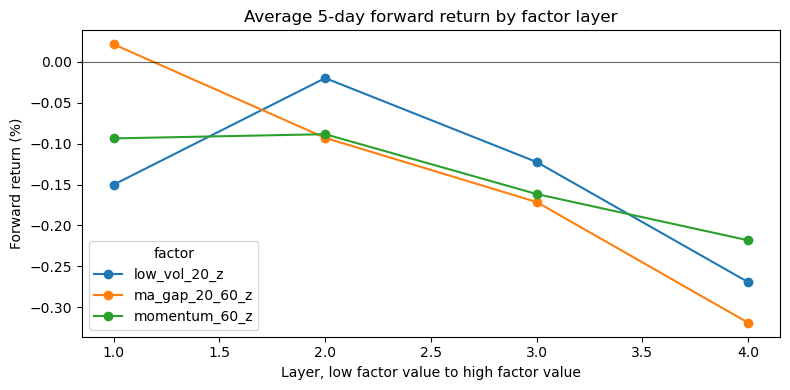

In [9]:
import matplotlib.pyplot as plt

ax = (layer_pivot * 100).plot(marker="o", figsize=(8, 4))
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set_title(f"Average {FORWARD_DAYS}-day forward return by factor layer")
ax.set_xlabel("Layer, low factor value to high factor value")
ax.set_ylabel("Forward return (%)")
ax.legend(title="factor")
plt.tight_layout()
plt.show()


## 7.8 保存 IC 汇总

本章只把 IC 汇总写入结果目录。分层表当前主要用于阅读和诊断，不作为后续 notebook 的硬依赖。


In [10]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ic_summary_path = RESULTS_DIR / "factor_ic_summary.csv"

ic_summary_to_save = ic_summary.copy()
ic_summary_to_save.insert(0, "forward_return", RETURN_COL)
ic_summary_to_save.to_csv(ic_summary_path, index=False, encoding="utf-8-sig")

output_info = pd.Series(
    {
        "path": str(ic_summary_path.relative_to(PROJECT_ROOT)),
        "rows": len(ic_summary_to_save),
        "methods": ", ".join(sorted(ic_summary_to_save["method"].unique())),
        "factors": ", ".join(ic_summary_to_save["factor"].unique()),
    }
)

display(output_info.to_frame("value"))
display(ic_summary_to_save.round(6))


,value
path,outputs\results\factor_ic_summary.csv
rows,6
methods,"pearson, spearman"
factors,"low_vol_20_z, ma_gap_20_60_z, momentum_60_z"


,forward_return,factor,method,ic_count,ic_mean,ic_std,ic_t_stat,ic_positive_rate,ic_abs_mean,avg_cross_section_n
0,fwd_ret_5d,low_vol_20_z,pearson,659,-0.010928,0.655055,-0.428241,0.499241,0.584527,4.0
1,fwd_ret_5d,ma_gap_20_60_z,pearson,659,-0.083520,0.646003,-3.318924,0.420334,0.572002,4.0
2,fwd_ret_5d,momentum_60_z,pearson,659,-0.011727,0.655128,-0.459522,0.500759,0.573241,4.0
3,fwd_ret_5d,low_vol_20_z,spearman,659,-0.010622,0.640438,-0.425773,0.464340,0.562974,4.0
4,fwd_ret_5d,ma_gap_20_60_z,spearman,659,-0.081942,0.650339,-3.234530,0.403642,0.577845,4.0
5,fwd_ret_5d,momentum_60_z,spearman,659,-0.015175,0.637921,-0.610648,0.458270,0.563278,4.0


## 7.9 质量检查与常见坑

本章的最低要求是：因子面板没有重复键，未来收益对齐后的有效样本不是空表，IC 汇总已经写出。最常见的坑是把 `close.pct_change(5)` 当成未来收益；它表示过去 5 日收益，需要再 `shift(-5)` 或直接用 `close.shift(-5) / close - 1`。


In [11]:
quality_checks = pd.Series(
    {
        "duplicate_date_code": int(research.duplicated(["date", "code"]).sum()),
        "non_null_forward_returns": int(research[RETURN_COL].notna().sum()),
        "ic_rows": len(ic_all),
        "ic_summary_rows": len(ic_summary_to_save),
        "layer_rows": len(layers),
        "unique_codes": research["code"].nunique(),
        "output_exists": ic_summary_path.exists(),
    }
)

display(quality_checks.to_frame("value"))

assert quality_checks["duplicate_date_code"] == 0
assert quality_checks["non_null_forward_returns"] > 0
assert quality_checks["ic_summary_rows"] > 0
assert quality_checks["output_exists"]


,value
duplicate_date_code,0
non_null_forward_returns,2636
ic_rows,3954
ic_summary_rows,6
layer_rows,7908
unique_codes,4
output_exists,True


## 7.10 练习：把观察窗口改成 20 日

改变未来收益窗口会改变问题本身：5 日更接近短期排序，20 日更接近月度持有。下面只给一个答案脚手架，读者可以替换成其他因子或其他窗口，比较 IC 是否稳定。


In [12]:
exercise_return_col = "fwd_ret_20d"
exercise_ic = ic_by_date_lib(research, ["momentum_60_z"], exercise_return_col, method="spearman", min_periods=3)
exercise_summary = summarize_ic(exercise_ic)

display(exercise_summary.round(4))


,factor,method,ic_count,ic_mean,ic_std,ic_t_stat,ic_positive_rate,ic_abs_mean,avg_cross_section_n
0,momentum_60_z,spearman,644,-0.1295,0.6277,-5.2359,0.368,0.5724,4.0


## 7.11 交接给第 08 章

本章回答的是“因子排序有没有初步值得检查的关系”。第 08 章会把标准化因子加权成 `score`，再把 `score` 转成 TopN 等权组合。进入组合构建前，应记住两点：

- IC 和分层只是体检，不是收益保证。
- 当前只有 4 只 ETF，后续回测结果也要按教学样例理解，不能外推成实盘结论。


In [13]:
handoff_scores = combine_score(
    factor_base,
    {"momentum_60": 0.45, "low_vol_20": 0.35, "ma_gap_20_60": 0.20},
)
latest_score_date = handoff_scores["date"].max()
latest_scores = (
    handoff_scores[handoff_scores["date"].eq(latest_score_date)]
    .sort_values("score", ascending=False)
    [["date", "code", *Z_FACTOR_COLS, "score"]]
)

display(latest_scores.round(4))


,date,code,momentum_60_z,low_vol_20_z,ma_gap_20_60_z,score
2655,2023-12-29,512100,1.3522,0.1888,1.1221,0.8990
2654,2023-12-29,510500,0.2693,1.0808,0.8365,0.6667
2653,2023-12-29,510300,-1.4370,0.3628,-1.2274,-0.7652
2652,2023-12-29,159915,-0.1844,-1.6324,-0.7312,-0.8006
